# Cadena de Racha de Éxitos

**Modelo de Luis Rincón (2012), §3.2, pp. 33–34**

Sea $\{\xi_1, \xi_2, \ldots\}$ una sucesión de ensayos de Bernoulli independientes con probabilidad de éxito $p$ y de fracaso $q = 1-p$. Se define $X_n$ como el número de éxitos consecutivos previos al tiempo $n$, incluyendo el tiempo $n$.

El espacio de estados es $S = \{0, 1, 2, \ldots\}$ y las probabilidades de transición son:

$$p_{ij} = \begin{cases} p & \text{si } j = i+1 \\ q & \text{si } j = 0 \\ 0 & \text{otro caso} \end{cases}$$

In [105]:
import tkinter as tk
from tkinter import ttk
import random
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np

#Parámetros iniciales para la simulación
p = 0.4    # Probabilidad de éxito 
q = 1 - p  # Probabilidad de fracaso 
N = 3    # Longitud de la racha a conseguir
racha_inicial = 0

### 1. Matrices de Transición

#### A) Matriz de Transición Original (Recurrente Continua)

$$P = \begin{pmatrix}
q & p & 0 & 0 & \cdots & 0 & 0 \\
q & 0 & p & 0 & \cdots & 0 & 0 \\
q & 0 & 0 & p & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
q & 0 & 0 & 0 & \cdots & 0 & p \\
q & p & 0 & 0 & \cdots & 0 & 0 
\end{pmatrix}$$

#### B) Matriz de Transición Modificada (Absorbente)

$$P = \begin{pmatrix}
q & p & 0 & 0 & \cdots & 0 & 0 \\
q & 0 & p & 0 & \cdots & 0 & 0 \\
q & 0 & 0 & p & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
q & 0 & 0 & 0 & \cdots & 0 & p \\
0 & 0 & 0 & 0 & \cdots & 0 & 1 
\end{pmatrix}$$

In [106]:
def construir_matriz_transicion(p: float, N: int) -> np.ndarray:
    q = 1 - p
    P = np.zeros((N + 1, N + 1))

    for estado_actual in range(N):
        P[estado_actual, estado_actual + 1] = p      # Éxito
        P[estado_actual, 0]                 = q      # Fracaso

    P[N, 1] = p      # Éxito
    P[N, 0] = q      # Fracaso
    
    return P

# Cálculo de matrices usando los parámetros globales
matriz_P = construir_matriz_transicion(p, N)

# Matriz absorbente
matriz_P_absorbente = matriz_P.copy()
matriz_P_absorbente[N, :] = 0.0  
matriz_P_absorbente[N, N] = 1.0   # 1 en la diagonal para hacer el estado N absorbente

def imprimir_matriz(matriz):
    # Estados destino
    print(" " * 15, end="")
    for destino in range(matriz.shape[1]):
        print(f"   {destino:^5}   ", end="")
    print("\n" + "-" * (15 + 8 * matriz.shape[1]))

    # Filas de la matriz
    for origen in range(matriz.shape[0]):
        print(f"      Estado {origen}     |", end="")
        for destino in range(matriz.shape[1]):
            valor = matriz[origen, destino]
            print(f"   {valor:5.2f}  ", end="")
        print()
    print("\n")

# Imprimir ambas versiones
imprimir_matriz(matriz_P)
imprimir_matriz(matriz_P_absorbente)

                    0          1          2          3     
-----------------------------------------------
      Estado 0     |    0.60      0.40      0.00      0.00  
      Estado 1     |    0.60      0.00      0.40      0.00  
      Estado 2     |    0.60      0.00      0.00      0.40  
      Estado 3     |    0.60      0.40      0.00      0.00  


                    0          1          2          3     
-----------------------------------------------
      Estado 0     |    0.60      0.40      0.00      0.00  
      Estado 1     |    0.60      0.00      0.40      0.00  
      Estado 2     |    0.60      0.00      0.00      0.40  
      Estado 3     |    0.00      0.00      0.00      1.00  




### 2. Parámetros iniciales y simulación

['p', 'p', 'q', 'q', 'p', 'q', 'p', 'p', 'q', 'p', 'p', 'q', 'q', 'q', 'q', 'q', 'q', 'q', 'p', 'q', 'q']


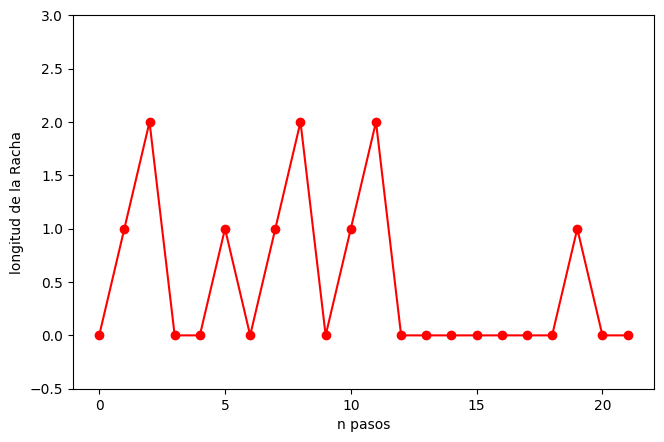

In [126]:
racha_actual = racha_inicial
historial_rachas = [racha_inicial]
historial_letras = [] 
corriendo = False

ultimo_modo_simulado = "Infinito"

def simular_paso():
    global racha_actual, corriendo, ultimo_modo_simulado
    
    if not corriendo:
        return  

    modo_elegido = combo_modo.get()
    ultimo_modo_simulado = modo_elegido

    # Ensayo de Bernoulli
    val = random.random()
    if val < p:
        historial_letras.append('p') 
        
        if modo_elegido == "Infinito":
            if racha_actual == N:
                racha_actual = 1  
            else:
                racha_actual += 1
                
        elif modo_elegido == "Absorbente":
            racha_actual += 1  
            
    else:
        historial_letras.append('q') 
        racha_actual = 0  

    # Guardar historial para la gráfica
    historial_rachas.append(racha_actual)
    if len(historial_rachas) > 50:  
        historial_rachas.pop(0)

    # Actualizar la gráfica
    ax.clear()
    ax.plot(historial_rachas, color="red", marker="o", linestyle="-")
    ax.set_ylabel("longitud de la Racha")
    ax.set_xlabel("n pasos") 
    ax.set_ylim(-0.5, max(max(historial_rachas) + 1, N))
    canvas.draw()

    # Parar en el caso finito absorbente al alcanzar la racha
    if modo_elegido == "Absorbente" and racha_actual == N:
        corriendo = False
        boton_iniciar.config(state="normal")
        boton_parar.config(state="disabled")
        combo_modo.config(state="readonly") 
        print(historial_letras)
        return

    ventana.after(500, simular_paso)

# Interfaz gráfica
def iniciar():
    global corriendo, racha_actual, historial_rachas, historial_letras
    if not corriendo:
        # Respetamos el parámetro inicial configurado en el Bloque 1
        racha_actual = racha_inicial
        historial_rachas = [racha_inicial]
        historial_letras = []
        
        corriendo = True
        boton_iniciar.config(state="disabled")
        boton_parar.config(state="normal")
        combo_modo.config(state="disabled") 
        simular_paso()

def parar():
    global corriendo
    corriendo = False
    boton_iniciar.config(state="normal")
    boton_parar.config(state="disabled")
    combo_modo.config(state="readonly") 
    print(historial_letras)

ventana = tk.Tk()
ventana.title("Simulador de Rachas de Éxitos")
ventana.geometry("750x550")

frame_controles = ttk.Frame(ventana)
frame_controles.pack(pady=15)

# Menú desplegable 
combo_modo = ttk.Combobox(frame_controles, values=["Infinito", "Absorbente"], width=20)
combo_modo.current(0) 
combo_modo.config(state="readonly")
combo_modo.pack(side="left", padx=10)

boton_iniciar = ttk.Button(frame_controles, text="Iniciar", command=iniciar)
boton_iniciar.pack(side="left", padx=5)

boton_parar = ttk.Button(frame_controles, text="Parar", command=parar, state="disabled")
boton_parar.pack(side="left", padx=5)

# Contenedor de la gráfica de Matplotlib
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=100)
canvas = FigureCanvasTkAgg(fig, master=ventana)
canvas.get_tk_widget().pack(pady=5, fill="both", expand=True)

ax.plot(historial_rachas, color="red", marker="o", linestyle="-")
ax.set_ylabel("longitud de la Racha")
ax.set_xlabel("n pasos")
ax.set_ylim(-0.5, N)
canvas.draw()

ventana.mainloop()

In [129]:
# Simulación rápida para el caso absorbente
racha_actual = 0  
historial_rachas = [0]
historial_letras = []

while racha_actual < N:
    val = random.random()
    if val < p:
        historial_letras.append('p')
        racha_actual += 1
    else:
        historial_letras.append('q')
        racha_actual = 0
    historial_rachas.append(racha_actual)

ultimo_modo_simulado = "Absorbente"
print(historial_letras)

['q', 'q', 'p', 'p', 'p']


### 3. Clases de comunicación

In [109]:
letras_simuladas = historial_letras
rachas_paso_a_paso = [0]
racha_actual = 0

es_absorbente = (ultimo_modo_simulado == "Absorbente")

for letra in letras_simuladas:
    if letra == 'p':
        if not es_absorbente and racha_actual == N:  
            racha_actual = 1
        else:
            racha_actual += 1  
    else:
        racha_actual = 0  
    rachas_paso_a_paso.append(racha_actual)

conexiones_encontradas = set()
for t in range(len(rachas_paso_a_paso) - 1):
    origen = rachas_paso_a_paso[t]
    destino = rachas_paso_a_paso[t+1]
    if origen != destino:  # Solo se guardan transiciones que cambian de estado
        conexiones_encontradas.add((origen, destino))

print("Estados accesibles:")
for origen, destino in sorted(conexiones_encontradas):
    print(f"  {origen} a {destino}")

estados_visitados = sorted(list(set(rachas_paso_a_paso)))  

print("\nClases de comunicación:")
if es_absorbente:
    # En el caso absorbente, los estados 0..N-1 son transitorios y N es una clase sola
    estados_transitorios = [e for e in estados_visitados if e < N]
    if estados_transitorios:
        cadena_transitorios = " = ".join(f"C({estado})" for estado in estados_transitorios)
        print(f"  Clase Transitoria: {cadena_transitorios}")
    if N in estados_visitados:
        print(f"  Clase Absorbente: C({N})")
else:
    # En el caso infinito, todos los estados visitados forman una sola clase
    cadena_igualdad = " = ".join(f"C({estado})" for estado in estados_visitados)
    print(f"  Clase Única (Irreducible): {cadena_igualdad}")

Estados accesibles:
  0 a 1
  1 a 0
  1 a 2
  2 a 0
  2 a 3

Clases de comunicación:
  Clase Transitoria: C(0) = C(1) = C(2)
  Clase Absorbente: C(3)


### 4. Clasificación de los estados

### 5. Periodos de los estados de la cadena

### 6. Calculos para la cadena de Markov

In [132]:
letras_simuladas = historial_letras
racha_prueba = 0
# Modo inicial según la última simulación registrada
es_absorbente = (ultimo_modo_simulado == "Absorbente")

# ciclo para verificar si la racha alcanzó el límite en el historial
for letra in letras_simuladas:
    if letra == 'p': 
        racha_prueba += 1
    else: 
        racha_prueba = 0
 
    if racha_prueba == N:
        es_absorbente = True

# Asignación de la matriz base según el modo (Infinito o absorbente)
if es_absorbente:
    P_base = matriz_P_absorbente
    N = P_base.shape[0] - 1 
    modo_tabla = "(Absorbente)"  
else:
    P_base = matriz_P 
    N = P_base.shape[0] - 1 
    modo_tabla = "(Infinito)"   

# Cálculo del vector de distribución inicial para el paso 0
pi_0 = np.zeros(N + 1)
pi_0[racha_inicial] = 1.0  
vector_entero = [int(x) for x in pi_0]
print(f" Distribución inicial π(0) = {vector_entero}") 

# Pasos del tiempo en los que evaluaremos la cadena de markov
pasos_analisis = [1, 2, 3, 4, 5, 10, 20, 30, 40]
ancho_columna = 10

# TABLA 1: probabilidades de transición generales (todas las combinaciones)

print()
print(f" Probabilidades de Transición en n Pasos {modo_tabla}")

# Generación de encabezados para todas las transiciones
encabezados_transicion = []
for i in range(N + 1):
    for j in range(N + 1):
        encabezados_transicion.append(f"π{i}{j}^(n)")

# linea para que se vea bonito
linea_transicion = "-" * (12 + ancho_columna * len(encabezados_transicion))
print(linea_transicion)
columnas_transicion_txt = "".join(f"{encab:<{ancho_columna}}" for encab in encabezados_transicion)
print(f"{'Pasos (n)':<12}{columnas_transicion_txt}")
print(linea_transicion)

# Cálculo de las potencias de la matriz para cada paso n
for n in pasos_analisis:
    P_n = np.linalg.matrix_power(P_base, n)
    
    todos_los_valores = []
    for i in range(N + 1):
        for j in range(N + 1):
            todos_los_valores.append(P_n[i, j])
            
    # Formateo de números a cuatro decimales y alineación de columnas para que se vea bonito
    valores_texto = "".join(f"{val:<{ancho_columna}.4f}" for val in todos_los_valores)
    print(f"{n:<12}{valores_texto}")

print(linea_transicion)

# TABLA 2: probabilidades de recurrencia (solo la diagonal i == j)

print()
print(f" Probabilidades de Recurrencia en n Pasos {modo_tabla}")

# Encabezados para la subtabla de recurrencias
encabezados_recurrencia = [f"π{i}{i}^(n)" for i in range(N + 1)]
linea_recurrencia = "-" * (12 + ancho_columna * len(encabezados_recurrencia))
print(linea_recurrencia)
columnas_recurrencia_txt = "".join(f"{encab:<{ancho_columna}}" for encab in encabezados_recurrencia)
print(f"{'Pasos (n)':<12}{columnas_recurrencia_txt}")
print(linea_recurrencia)

# Valores de recurrencia
for n in pasos_analisis:
    P_n = np.linalg.matrix_power(P_base, n)
    valores_recurrencia = [P_n[i, i] for i in range(N + 1)]
    valores_recurrencia_txt = "".join(f"{val:<{ancho_columna}.4f}" for val in valores_recurrencia)
    print(f"{n:<12}{valores_recurrencia_txt}")

print(linea_recurrencia)

 Distribución inicial π(0) = [1, 0, 0, 0]

 Probabilidades de Transición en n Pasos (Absorbente)
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Pasos (n)   π00^(n)   π01^(n)   π02^(n)   π03^(n)   π10^(n)   π11^(n)   π12^(n)   π13^(n)   π20^(n)   π21^(n)   π22^(n)   π23^(n)   π30^(n)   π31^(n)   π32^(n)   π33^(n)   
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1           0.6000    0.4000    0.0000    0.0000    0.6000    0.0000    0.4000    0.0000    0.6000    0.0000    0.0000    0.4000    0.0000    0.0000    0.0000    1.0000    
2           0.6000    0.2400    0.1600    0.0000    0.6000    0.2400    0.0000    0.1600    0.3600    0.2400    0.0000    0.4000    0.0000    0.0000    0.0000    1.0000    
3           0.6000    0.2400    0.0960